In [1]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 

# Abstraction


Assume we have a set of products that represented by matrix $P$ where each product is presented by vector $p$. Now, we want to list all of 
top (eg: 10) product that they are the most similar with product $p_i$.

# Solution

From matrix $P$, we compute covariance matrix $Q$, that is formed:
$$
\begin{aligned}
Q = P \cdot P^T \\
\end{aligned}
$$

The, the similar score of $p_i$ will be $q_i$, to get the top similarity of $p_i$:
    $$top_i = argmax(q_i)$$

(we also ignore product $i$ in the top_i as itself similar score is 1)

<Axes: >

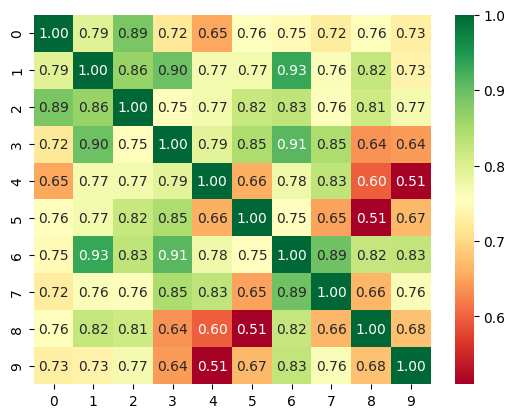

In [45]:
products = np.random.random(size=(10, 10))
norm_products = products/np.linalg.norm(products, axis=1)[:, None]
Q = np.dot(norm_products, norm_products.T)

sns.heatmap(Q, annot=True, fmt='.2f', cmap='RdYlGn')

In [48]:
def get_top_similar(Q, i, top = 3, removed_itseft = True):
    top_index = np.argpartition(Q[i], -top)[-top:]
    if removed_itseft:
        top_index = np.delete(top_index, i)
    return top_index, Q[i][top_index]


get_top_similar(Q, 0)

(array([2, 0]), array([0.88550876, 1.        ]))